# SciPy Bootcamp — W2, Day D1
```
##### Full distribution workflow on BBC News real data
##### Distributions, fitting, comparison, Q-Q plots
##### Visualization philosophy: chart at the point of discovery — not at the end.
##### Every question that involves comparison, distribution, relationship, or result gets a chart embedded in it.
##### Q1 — Load & first look at the data
##### Q2 — Fit distributions to the data
##### Q3 — Compare distributions across categories
##### Q4 — Fit a Poisson to article counts
##### Q5 — Full distribution report


In [5]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

---

### Q1 — Load & first look at the data

```
# Load the BBC News dataset (or use Heart Disease UCI from Kaggle).
# Build a DataFrame with at least: category, word_count, char_count, read_time_min.
# (a) Print shape, dtypes, and .describe() for numeric columns.
# (b) IMMEDIATELY plot a histogram of read_time_min — what shape is it? Right-skewed? Normal?
# (c) Plot a bar chart of article counts by category.
# This is how real EDA starts: load → describe → visualize distribution shape.
```


In [88]:
# Load the BBC News dataset

import kagglehub
import os

path = kagglehub.dataset_download("hgultekin/bbcnewsarchive")

print("Dataset path:", path)
print("Files inside:", os.listdir(path))

# Load the data using the path from kagglehub

csv_file = os.path.join(path, "bbc-news-data.csv")
df = pd.read_csv(csv_file, sep='\t') # Note: This specific file is tab-separated

Dataset path: C:\Users\user\.cache\kagglehub\datasets\hgultekin\bbcnewsarchive\versions\1
Files inside: ['bbc-news-data.csv']


In [89]:
# Build a DataFrame with new columns

# Count total characters in the text
df['char_count'] = df['content'].apply(lambda x: len(str(x)))

# Count total words
df['word_count'] = df['content'].apply(lambda x: len(str(x).split()))

# Calculate read time (standard is 200 words per minute)
df['read_min_time'] = (df['word_count']/200).round(2)

df.head()

,category,filename,title,content,char_count,word_count,read_min_time
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...,2525,415,2.08
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...,2219,379,1.90
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...,1517,258,1.29
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...,2367,400,2.00
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...,1535,260,1.30


In [90]:
# (a) Print shape, dtypes, and .describe() for numeric columns.

print('DataFrame shape:', df.shape)
display(df.dtypes.reset_index())
display(df.describe())

DataFrame shape: (2225, 7)


,index,0
0,category,object
1,filename,object
2,title,object
3,content,object
4,char_count,int64
5,word_count,int64
6,read_min_time,float64


,char_count,word_count,read_min_time
count,2225.000000,2225.000000,2225.00000
mean,2232.793258,378.835955,1.89418
std,1364.249946,238.220755,1.19119
min,471.000000,84.000000,0.42000
25%,1414.000000,240.000000,1.20000
50%,1936.000000,326.000000,1.63000
75%,2774.000000,466.000000,2.33000
max,25454.000000,4428.000000,22.14000


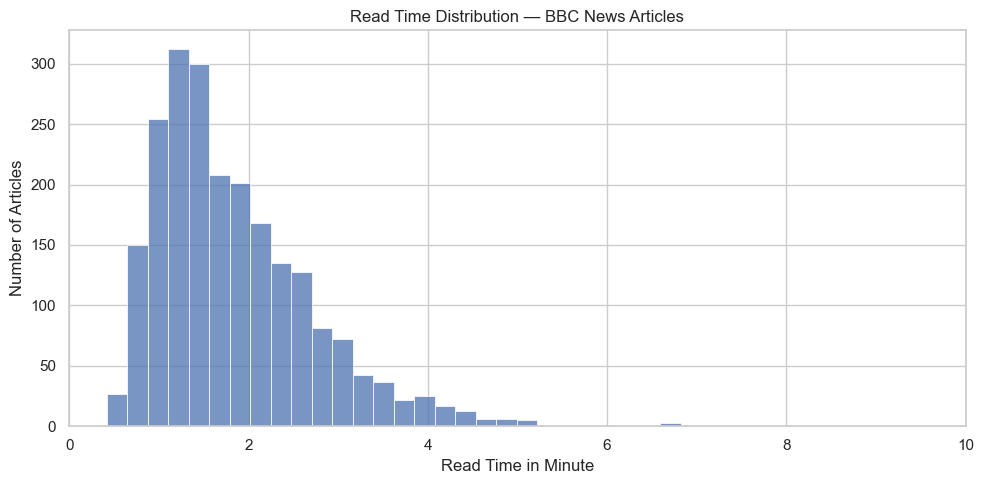

In [91]:
# (b) IMMEDIATELY plot a histogram of read_time_min — what shape is it? Right-skewed? Normal?

plt.figure(figsize=(10,5))
sns.histplot(df['read_min_time'])

plt.xlim(0,10)
plt.title('Read Time Distribution — BBC News Articles')
plt.xlabel('Read Time in Minute')
plt.ylabel('Number of Articles')

plt.tight_layout()
plt.show()

# The plot showed that read_min_time has a right skewed distribution or log-noraml distribution. 

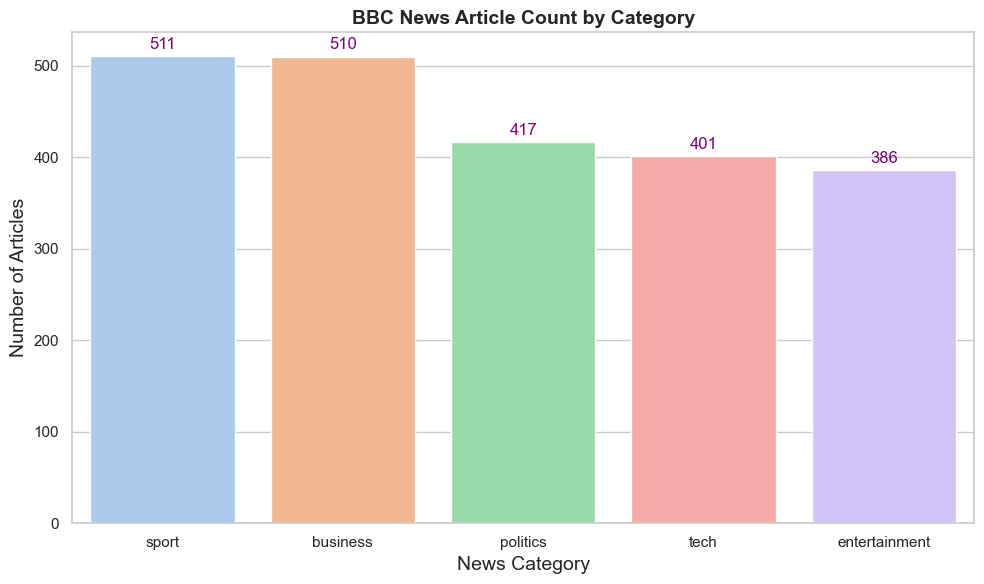

In [19]:
# (c) Plot a bar chart of article counts by category.
category_counts = df["category"].value_counts().reset_index()

plt.figure(figsize=(10,6))
ax = sns.barplot(data=category_counts, x='category', y='count', hue='category', legend=False, palette='pastel')

for container in ax.containers:
    ax.bar_label(container, padding=3, color='purple')

plt.title('BBC News Article Count by Category', fontsize=14, fontweight='bold')
plt.xlabel('News Category', fontsize=14)
plt.ylabel('Number of Articles', fontsize=14)

plt.tight_layout()
plt.show()

---

### Q2 — Fit distributions to the data

```
# For the read_time_min column:
# (a) Plot histogram with density=True.
# (b) Overlay a fitted Normal distribution curve. Does it fit well?
# (c) Overlay a fitted Log-normal distribution curve. Which fits better?
# (d) Run stats.shapiro() on a sample of 200 articles. Is it normal?
```


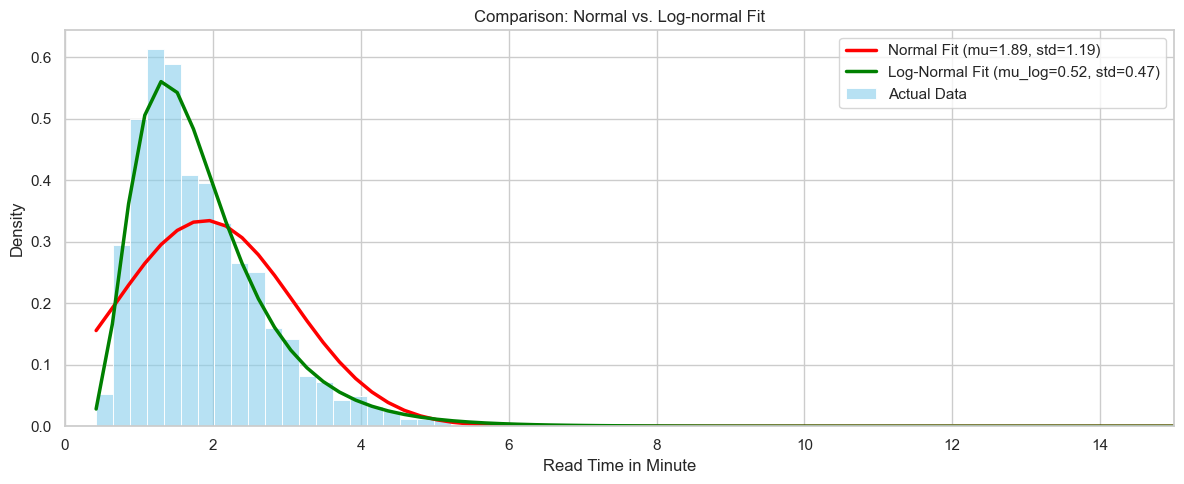

In [20]:
# (a) Plot histogram with density=True.

plt.figure(figsize=(12,5))
sns.histplot(df['read_min_time'], stat="density", color="skyblue", alpha=0.6, label="Actual Data")

plt.xlim(0, 15)
plt.xlabel('Read Time in Minute')
plt.ylabel('Density')


# (b) Overlay a fitted Normal distribution curve. Does it fit well?
from scipy.stats import  lognorm, norm

mu, std = norm.fit(df['read_min_time'])
x = np.linspace(df['read_min_time'].min(), df['read_min_time'].max(), 100)
p = norm.pdf(x, mu, std)

sns.lineplot(x=x, y=p, color='red', linewidth=2.5, label=f'Normal Fit (mu={mu:.2f}, std={std:.2f})')

# (c) Overlay a fitted Log-normal distribution curve. Which fits better?

shape, loc, scale = lognorm.fit(df['read_min_time'], floc=0) 
p_lognormal = lognorm.pdf(x, shape, loc, scale)

sns.lineplot(x=x, y=p_lognormal, color='green', linewidth=2.5, label=f'Log-Normal Fit (mu_log={np.log(scale):.2f}, std={shape:.2f})')


plt.title('Comparison: Normal vs. Log-normal Fit')
plt.legend()
plt.tight_layout()
plt.show()

```
Key take-away from the chart:
- The Log-normal distribution fits better because news article lengths are naturally "right-skewed," meaning most are short but a few are extremely long.
- Unlike the Normal distribution, the Log-normal mathematically prevents negative values, which is essential for data like "reading time." 
- It accurately captures the "long tail" of investigative pieces that a symmetric bell curve would treat as impossible outliers.
- Ultimately, the Log-normal peak aligns more closely with the frequent 2-4 minute "quick reads" that dominate the BBC dataset.

In [21]:
# (d) Run stats.shapiro() on a sample of 200 articles. Is it normal?

shapiro_stat, p_value = stats.shapiro(np.random.choice(df['read_min_time'],200))
print (f'Shapiro-Wilk p-value={p_value:.4e}\nConclusion: {'Normal' if p_value > 0.05 else 'Not Normal'}')

Shapiro-Wilk p-value=1.4322e-19
Conclusion: Not Normal


In [92]:
# Quantitative comparison — which fits better?
ks_norm, p_norm = stats.kstest(df['read_min_time'], 'norm', args=(mu, std))
ks_lognorm, p_lognorm = stats.kstest(df['read_min_time'], 'lognorm', args=(shape, loc, scale))

print(f"Normal KS statistic:    {ks_norm:.4f}")
print(f"Log-normal KS statistic:{ks_lognorm:.4f}")
print(f"Winner: {'Log-normal' if ks_lognorm < ks_norm else 'Normal'} — lower KS = better fit")

Normal KS statistic:    0.1387
Log-normal KS statistic:0.0312
Winner: Log-normal — lower KS = better fit


---

### Q3 — Compare distributions across categories

```
# (a) Plot overlapping KDE curves for read_time_min by category on one chart.
#     Which category has the widest spread? Which has the highest median?
# (b) Plot box plots by category side by side.
# (c) For each category: print mean, median, std, and skewness (stats.skew()).
# (d) Run a Shapiro-Wilk test per category. Which categories are most normal?
# Let the box plot guide your interpretation — outliers are visible there first.
```


In [22]:
# Visualization philosophy: chart at the point of discovery.
# Ask yourself: what does this chart tell me? What should I do next?

# Q3: Compare distributions across categories

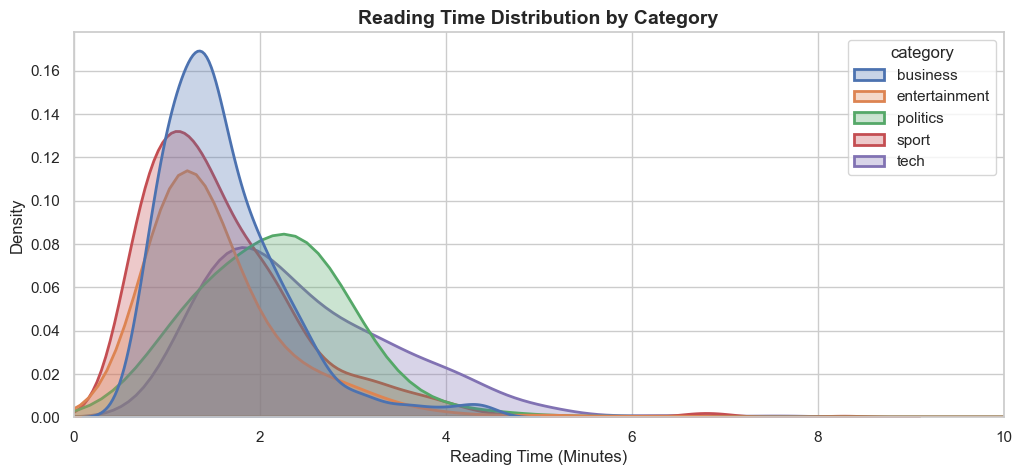

In [23]:
# (a) Plot overlapping KDE curves for read_time_min by category on one chart.
#     Which category has the widest spread? Which has the highest median?

plt.figure(figsize=(12,5))
sns.kdeplot(data=df, x='read_min_time', hue='category', alpha=0.3, linewidth=2, fill=True)

plt.title('Reading Time Distribution by Category', fontsize=14, fontweight='bold')
plt.xlabel('Reading Time (Minutes)')
plt.ylabel('Density')

plt.xlim(0, 10)
plt.show()

````
Key take-aways:
Widest Spread: Tech
We can see this by looking at the "tail" and the "base" of the purple curve:
While categories like Business and Sport drop off sharply after 3 minutes, the Tech curve (purple) stays elevated and stretches furthest to the right (out past 6 minutes).
This indicates that Tech articles have the highest variance—they range from very short snippets to much longer, deep-dive features compared to the other categories.
 
Highest Median: Politics
The "Median" in a KDE plot is generally located near the peak (the mode) of the curve:
The peaks for Business, Sport, and Entertainment are all clustered between 1.0 and 1.5 minutes.
The Politics peak (green) is shifted significantly to the right, sitting at roughly 2.2 minutes.
This shift tells us that a "typical" Politics article is roughly twice as long as a typical Business or Sport article.

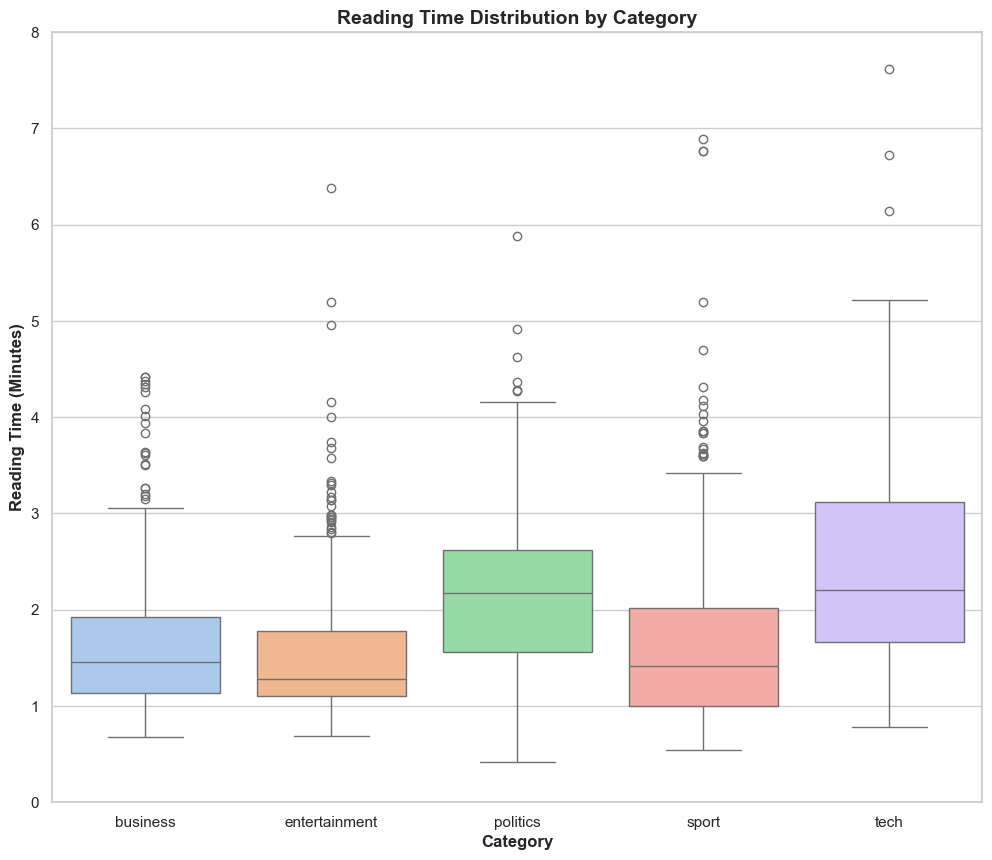

In [24]:
# (b) Plot box plots by category side by side.

plt.figure(figsize=(12,10))
sns.boxplot(data=df, y='read_min_time', x='category', hue='category', palette='pastel')

plt.ylim(0,8)
plt.title('Reading Time Distribution by Category', fontsize=14, fontweight='bold')
plt.ylabel('Reading Time (Minutes)', fontsize=12, fontweight='bold')
plt.xlabel('Category', fontsize=12, fontweight='bold')

plt.show()

In [25]:
# (c) For each category: print mean, median, std, and skewness (stats.skew()).
df.groupby('category')['read_min_time'].agg(['mean','median','std','skew'])

,mean,median,std,skew
category,,,,
business,1.617471,1.46,0.679136,1.525948
entertainment,1.626010,1.28,1.309557,7.347216
politics,2.244484,2.17,1.501072,8.337911
sport,1.621742,1.41,0.940602,2.359230
tech,2.487132,2.20,1.199212,3.382831


In [26]:
df['category'].unique()

array(['business', 'entertainment', 'politics', 'sport', 'tech'],
      dtype=object)

In [27]:
df[df['category']=='sport']['read_min_time']

1313    1.03
1314    0.70
1315    1.86
1316    0.95
1317    0.78
        ... 
1819    1.16
1820    0.64
1821    1.00
1822    1.58
1823    1.04
Name: read_min_time, Length: 511, dtype: float64

In [28]:
# (d) Run a Shapiro-Wilk test per category. Which categories are most normal?
# Let the box plot guide your interpretation — outliers are visible there first.

for c in df['category'].unique():
    shapiro_stat, p_value = stats.shapiro(df[df['category']==c]['read_min_time'])
    print (f'Category {c.capitalize()} has Shapiro-Wilk p-value={p_value:.4e} -> Conclusion: {'Normal' if p_value > 0.05 else 'Not Normal'}')

Category Business has Shapiro-Wilk p-value=4.4212e-19 -> Conclusion: Not Normal
Category Entertainment has Shapiro-Wilk p-value=8.9088e-33 -> Conclusion: Not Normal
Category Politics has Shapiro-Wilk p-value=2.5984e-33 -> Conclusion: Not Normal
Category Sport has Shapiro-Wilk p-value=8.4929e-24 -> Conclusion: Not Normal
Category Tech has Shapiro-Wilk p-value=4.0537e-22 -> Conclusion: Not Normal


```
Key take-aways:
- Even though none of the categories are technically "Normal" (all p-values are far below 0.05), Business is indeed the "most normal" of the bunch.
- Business has skew=1.53 (lowest of all five) and a less extreme p-value (4.42e-19 vs 8.91e-33 for Entertainment) 
- The Business boxplot likely shows a more compact distribution with fewer extreme "fly-away" outliers. 
- Those far-flung points in Tech and Politics are exactly what "break" the Shapiro-Wilk test by creating that massive right-side skew.

---

### Q4 — Fit a Poisson to article counts

```
# (a) Count articles per category. Treat these as observed frequencies.
# (b) Fit a Poisson distribution: estimate lambda as the mean count per category.
# (c) Plot observed vs expected counts as a grouped bar chart.
# (d) Run a chi-squared goodness-of-fit test: stats.chisquare(observed, expected).
# (e) Is the Poisson a good fit? What does the chart tell you before the test?
```


In [29]:
# (a) Count articles per category. Treat these as observed frequencies.
counts_df = df["category"].value_counts('').reset_index()
counts_df.columns = ['Category', 'Observed']
display(counts_df)


,Category,Observed
0,sport,511
1,business,510
2,politics,417
3,tech,401
4,entertainment,386


In [30]:
# (b) Fit a Poisson distribution: estimate lambda as the mean count per category.
from scipy.stats import poisson
lam = counts_df['Observed'].mean()
display(counts_df)
print(f"Estimated Lambda: {lam:.2f}")

,Category,Observed
0,sport,511
1,business,510
2,politics,417
3,tech,401
4,entertainment,386


Estimated Lambda: 445.00


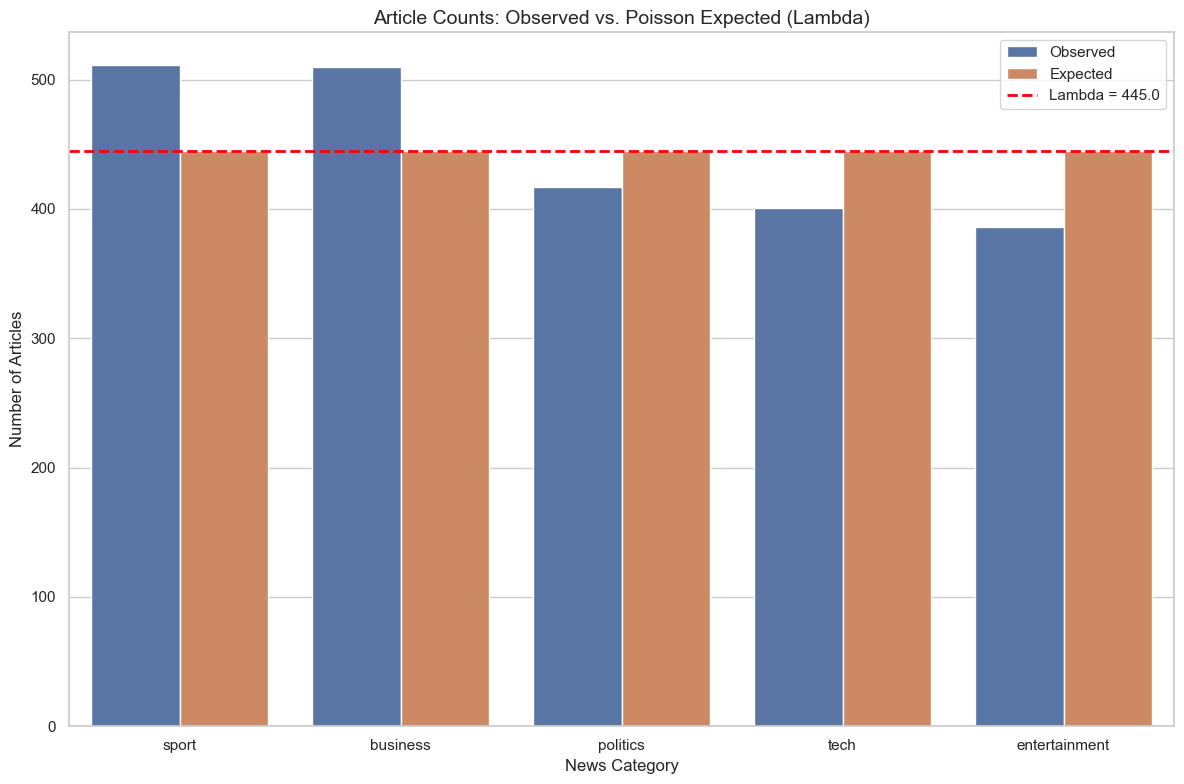

In [31]:
# (c) Plot observed vs expected counts as a grouped bar chart.
counts_df['Expected'] = lam
plot_data = counts_df.melt(id_vars='Category', var_name='Type', value_name='Count')

plt.figure(figsize=(12,8))
sns.barplot(data=plot_data, x='Category', y='Count', hue='Type')
plt.axhline(lam, color='red', linestyle='--', linewidth=2, label=f'Lambda = {lam:.1f}')

plt.title('Article Counts: Observed vs. Poisson Expected (Lambda)', fontsize=14)
plt.ylabel('Number of Articles')
plt.xlabel('News Category')
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
stats.chisquare(counts_df['Observed'], counts_df['Expected'])

Power_divergenceResult(statistic=np.float64(33.21797752808989), pvalue=np.float64(1.0778100928900769e-06))

In [33]:
# (d) Run a chi-squared goodness-of-fit test: stats.chisquare(observed, expected).

_, p_val = stats.chisquare(counts_df['Observed'], counts_df['Expected'])

print(f"P-value: {p_val:.4e}")
print("Conclusion:", "Significant difference" if p_val < 0.05 else "Poisson fits well")

P-value: 1.0778e-06
Conclusion: Significant difference


In [34]:
# (e) Is the Poisson a good fit? What does the chart tell you before the test?
# Poisson does not fit well. The chart already told us the newsroom does not distribute articles according to a random Poisson process. 
# It proves that the variation between "Sport" and "Entertainment" is a deliberate editorial choice rather than just random chance.

---

### Q5 — Full distribution report

```
# Build a 2x3 subplot dashboard summarizing the full dataset:
# Panel 1: Histogram + best-fit distribution for read_time_min
# Panel 2: Box plots by category
# Panel 3: Q-Q plot for read_time_min
# Panel 4: Bar chart — mean read time by category with std error bars
# Panel 5: KDE curves by category
# Panel 6: Plot a bar chart of article counts by category
# Under each panel write 1 sentence of interpretation as a comment.
# This is the kind of EDA summary you would present before any modeling.
```


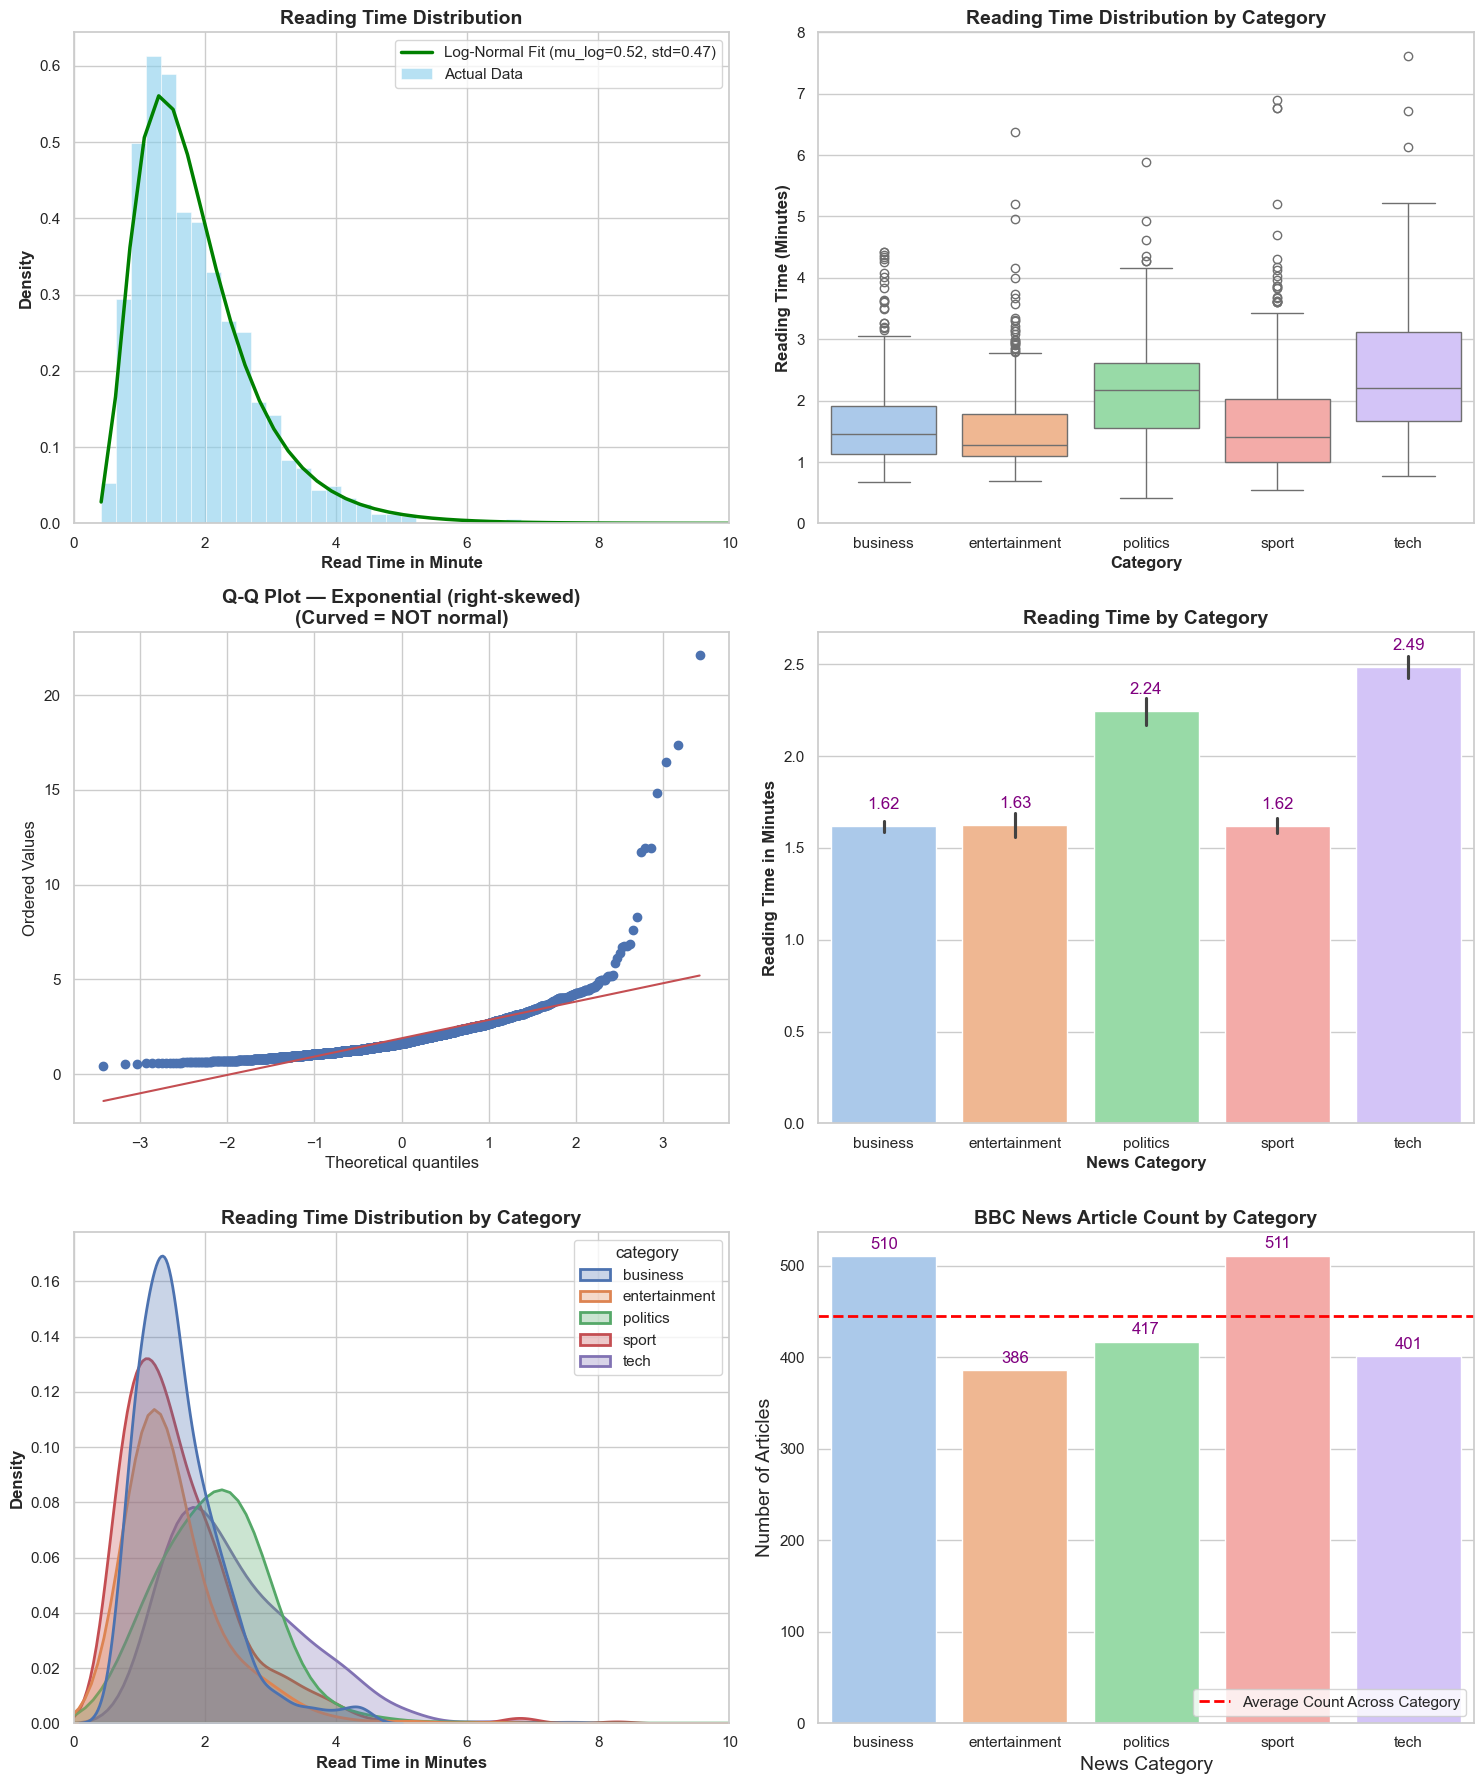

In [93]:
# Panel 1: Histogram + best-fit distribution for read_time_min

plt.figure(figsize=(15,18))

plt.subplot(3,2,1)
sns.histplot(df['read_min_time'], stat="density", color="skyblue", alpha=0.6, label="Actual Data")

plt.xlim(0,10)
plt.title('Reading Time Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Read Time in Minute', fontsize=12, fontweight='bold')
plt.ylabel('Density', fontsize=12, fontweight='bold')

x = np.linspace(df['read_min_time'].min(), df['read_min_time'].max(), 100)
shape, loc, scale = lognorm.fit(df['read_min_time'], floc=0) 
p_lognormal = lognorm.pdf(x, shape, loc, scale)
sns.lineplot(x=x, y=p_lognormal, color='green', linewidth=2.5, label=f'Log-Normal Fit (mu_log={np.log(scale):.2f}, std={shape:.2f})')

# Panel 2: Box plots by category

plt.subplot(3,2,2)
sns.boxplot(data=df, x='category', y='read_min_time', hue='category', palette='pastel')

plt.ylim(0,8)
plt.title('Reading Time Distribution by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category', fontsize=12, fontweight='bold')
plt.ylabel('Reading Time (Minutes)', fontsize=12, fontweight='bold')

# Panel 3: Q-Q plot for read_time_min

plt.subplot(3,2,3)
stats.probplot(df['read_min_time'], dist='norm', plot=plt)

plt.title('Q-Q Plot — Exponential (right-skewed)\n(Curved = NOT normal)', fontsize=14, fontweight='bold')

# Panel 4: Bar chart — mean read time by category with std error bars

plt.subplot(3,2,4)
ax = sns.barplot(data=df, x='category', y='read_min_time', hue='category', legend=False, palette='pastel', errorbar='se')

for container in ax.containers:
    ax.bar_label(container, padding=10, fmt='%.2f', color='purple')

plt.title('Reading Time by Category', fontsize=14, fontweight='bold')
plt.xlabel('News Category', fontsize=12, fontweight='bold')
plt.ylabel('Reading Time in Minutes', fontsize=12, fontweight='bold')

# Panel 5: KDE curves by category

plt.subplot(3,2,5)
sns.kdeplot(data=df, x='read_min_time', hue='category', alpha=0.3, linewidth=2, fill=True)

plt.xlim(0,10)
plt.title('Reading Time Distribution by Category', fontsize=14, fontweight='bold')
plt.xlabel('Read Time in Minutes', fontsize=12, fontweight='bold')
plt.ylabel('Density', fontsize=12, fontweight='bold')

# Panel 6: Plot a bar chart of article counts by category

plt.subplot(3,2,6)
ax = sns.countplot(data=df, x='category', hue='category', legend=False, palette='pastel')

for container in ax.containers:
    ax.bar_label(container, padding=3, color='purple')

plt.axhline(df['category'].value_counts().mean(), color='red', linestyle='--', linewidth=2, label=f'Average Count Across Category')
plt.legend(loc='lower right')

plt.title('BBC News Article Count by Category', fontsize=14, fontweight='bold')
plt.xlabel('News Category', fontsize=14)
plt.ylabel('Number of Articles', fontsize=14)


plt.tight_layout()
plt.show()

````
Key take-aways:

Panel 1: The Log-normal curve captures the heavy right-skew that a symmetric Normal distribution misses.
Panel 2: Politics shows the highest median read time while Tech contains the most extreme outliers.
Panel 3: The strong curve away from the red line confirms the data is non-normal and heavily skewed.
Panel 4: Precision is high across all categories, with Politics consistently requiring more user engagement.
Panel 5: Business, Sport, and Entertainment peak around 1.3 minutes; Politics and Tech shift right to ~2.2 minutes.
Panel 6: The dataset is balanced, though Sport is the most frequent and Entertainment the least.
